In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import files
uploaded=files.upload()
print(uploaded)

Saving Customer Churn.csv to Customer Churn.csv
{'Customer Churn.csv': b'PK\x03\x04\n\x00\x00\x00\x00\x00\x87N\xe2@\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\t\x00\x00\x00docProps/PK\x03\x04\x14\x00\x00\x00\x08\x00\x87N\xe2@u\'!$9\x01\x00\x00@\x02\x00\x00\x10\x00\x00\x00docProps/app.xml\x9d\x91\xc1J\xc40\x10\x86\xef\x82\xef\x10r\xd2\x83\x9b\xed""K\x9bEV\xc4\x9b\x85]\xf5\x1c\xd3\xe96\xd0&%3[v}\x16/\x1e\x04\xdf\xc0\x93o\xa3\xe0c\x98\xb6\xa0]\xf5\xe4\xed\x9f\xfc\xc3?\xdfO\xe2\xd9\xa6*Y\x03\x1e\x8d\xb3\t\x8fFc\xce\xc0j\x97\x19\xbbJ\xf8\xf5\xf2\xe2\xe8\x943$e3U:\x0b\t\xdf\x02\xf2\x99\xdc\xdf\x8bS\xefj\xf0d\x00Y\x88\xb0\x98\xf0\x82\xa8\x9e\n\x81\xba\x80J\xe1(\xd868\xb9\xf3\x95\xa20\xfa\x95pyn4\x9c;\xbd\xae\xc0\x92\x98\x8c\xc7\'\x026\x046\x83\xec\xa8\xfe\n\xe4}\xe2\xb4\xa1\xff\x86fN\xb7|x\xb3\xdc\xd6\x01X\xc6gu]\x1a\xad(\xb4\x94\xb7\xe9\x82-\n\x00\xc2X\x0c\xdf\xe3KPm\xefT\x19\x8f2nh\xda\x80&\xe7\x19\x9a\xfb\xd0|\xc2\xd9\x9dBh\x13\x13\xde(o\x94\xa5\x90\xdc\xae\xf5C\xa7\xcb\x1a\xc9\xcb\xf

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
import zipfile
import io
import pandas as pd

# Get the content of the uploaded file.
# The file named 'Customer Churn.csv' was detected as an Excel (.xlsx) file,
# which is itself a compressed archive.
file_content = uploaded['Customer Churn.csv']

# Use io.BytesIO to treat the byte string as a file-like object
file_object = io.BytesIO(file_content)

try:
    # Try to read the file as an Excel file
    df = pd.read_excel(file_object)
    print("Successfully loaded data as an Excel file.")
except Exception as e:
    print(f"Could not read as Excel: {e}")
    print("Attempting to read as a CSV after unzipping, if it's a general zip file.")
    # Fallback for general zip files, though unlikely given the file_list from previous run
    try:
        with zipfile.ZipFile(file_object, 'r') as zf:
            file_list = zf.namelist()
            csv_file_name = None

            for name in file_list:
                if name.endswith('.csv'):
                    csv_file_name = name
                    break

            if csv_file_name:
                with zf.open(csv_file_name) as f:
                    df = pd.read_csv(f)
                    print(f"Successfully loaded '{csv_file_name}' from the zip file.")
            else:
                print("No CSV file found inside the zip archive.")
                print(f"Files inside the zip: {file_list}")
                df = None # Ensure df is not defined if no CSV found
    except zipfile.BadZipFile:
        print("The uploaded file is not a valid zip archive either.")
        df = None

if df is not None:
    print("Displaying the first 5 rows of the DataFrame:")
    df.head()
else:
    print("Could not load data into a DataFrame. Please check the file format.")

Successfully loaded data as an Excel file.
Displaying the first 5 rows of the DataFrame:


In [5]:
df = pd.read_csv('/content/Customer Churn.csv')
df.head()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0x87 in position 10: invalid start byte

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df["TotalCharges"]= df["TotalCharges"].replace(" ","0")
df["TotalCharges"]= df["TotalCharges"].astype("float")

In [8]:
#replacing blanks with 0 as tenure is 0 and no total charges are recorded

In [9]:
df.isnull()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7039,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7040,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["customerID"].duplicated().sum()

np.int64(0)

#coverted 0 and 1 values of senior citizen to yes/no to make it easier to understand

In [15]:
def conv(value):
  if value==1:
    return"yes"
  else:
    return "no"
df["SeniorCitizen"]=df["SeniorCitizen"].apply(conv)

In [16]:
df.head(20)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,no,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,no,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,no,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,no,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,no,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


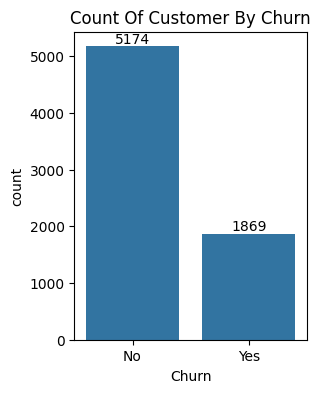

In [18]:
plt.figure(figsize=(3,4))
ax=sns.countplot(x='Churn',data=df)

ax.bar_label(ax.containers[0])
plt.title("Count Of Customer By Churn")
plt.show()

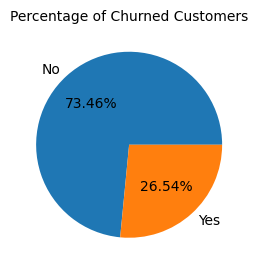

In [19]:
plt.figure(figsize=(3,4))
gb = df.groupby("Churn").agg({'Churn':'count'})
plt.pie(gb['Churn'],labels= gb.index,autopct="%1.2f%%")

plt.title("Percentage of Churned Customers",fontsize=10)
plt.show()

# FROM THE GIVEN PIE CHART WE CAN CONCLUDE THAT 26.54% OF OUR CUSTOMERS HAVE CHURNED OUT
# NOT LET'S EXPLORE THE REASON BEHIND IT

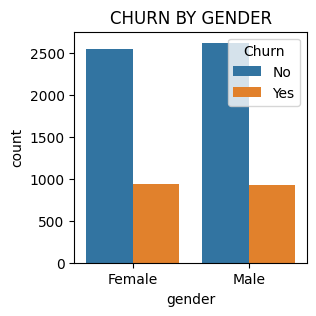

In [20]:
plt.figure(figsize=(3,3))
sns.countplot(x="gender",data=df,hue="Churn")
plt.title("CHURN BY GENDER")
plt.show()

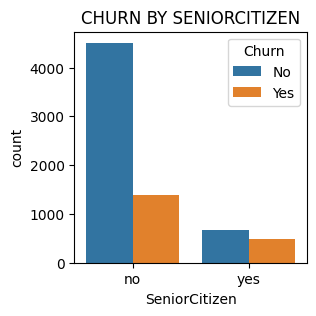

In [21]:
plt.figure(figsize=(3,3))
sns.countplot(x="SeniorCitizen",data=df,hue="Churn")
plt.title("CHURN BY SENIORCITIZEN")
plt.show()

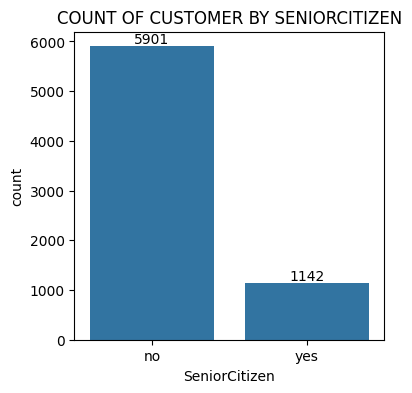

In [22]:
plt.figure(figsize=(4,4))
ax=sns.countplot(x="SeniorCitizen",data=df)
ax.bar_label(ax.containers[0])
plt.title("COUNT OF CUSTOMER BY SENIORCITIZEN")
plt.show()

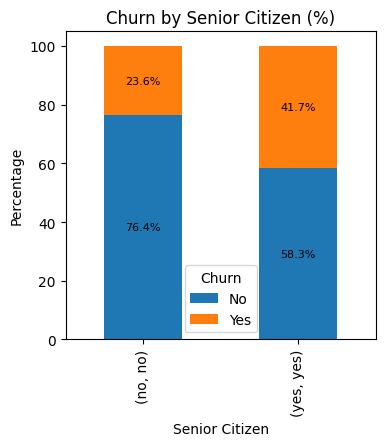

In [23]:
#Create percentage table
churn_pct = (
    df.groupby(['SeniorCitizen', 'Churn'])
      .size()
      .groupby(level=0)
      .apply(lambda x: x / x.sum() * 100)
      .unstack()
)

# Plot stacked bar chart
churn_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(4,4)
)

plt.title("Churn by Senior Citizen (%)")
plt.ylabel("Percentage")
plt.xlabel("Senior Citizen")
plt.legend(title="Churn")

# Add percentage labels
for i, (idx, row) in enumerate(churn_pct.iterrows()): # Use enumerate to get numerical index 'i'
    cumulative = 0
    for val in row:
        if val > 0:
            plt.text(
                i, # Use the numerical index for x-coordinate
                cumulative + val / 2,
                f"{val:.1f}%",
                ha='center',
                va='center',
                fontsize=8
            )
        cumulative += val

plt.show()

#comparitively a greater percentage of people in senior citizen category have churned out

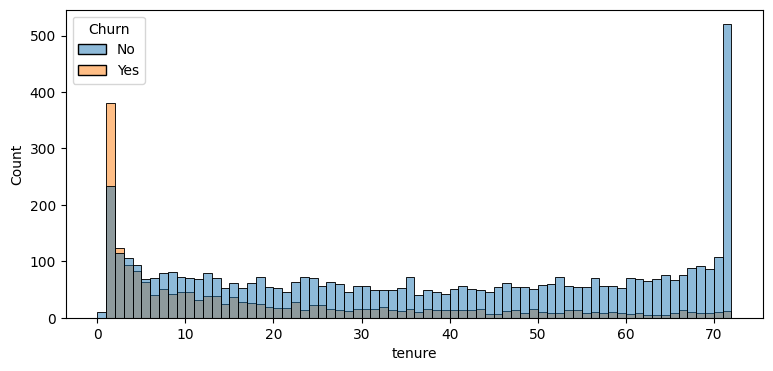

In [27]:
plt.figure(figsize=(9,4))
sns.histplot(x="tenure",data=df,bins=72,hue="Churn")
plt.show()

#people who have used our services for a long time have stayed and people who have usedour services for 1 or 2 months have churned


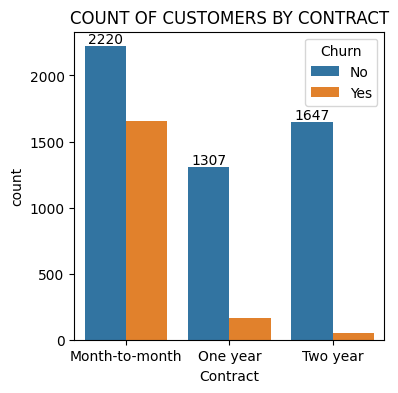

In [34]:
plt.figure(figsize=(4,4))
ax=sns.countplot(x="Contract",data=df,hue="Churn")
ax.bar_label(ax.containers[0])
plt.title("COUNT OF CUSTOMERS BY CONTRACT")
plt.show()

#people who have month to month contract are likely to churn then from those who have 1 or 2 years of contract

In [35]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

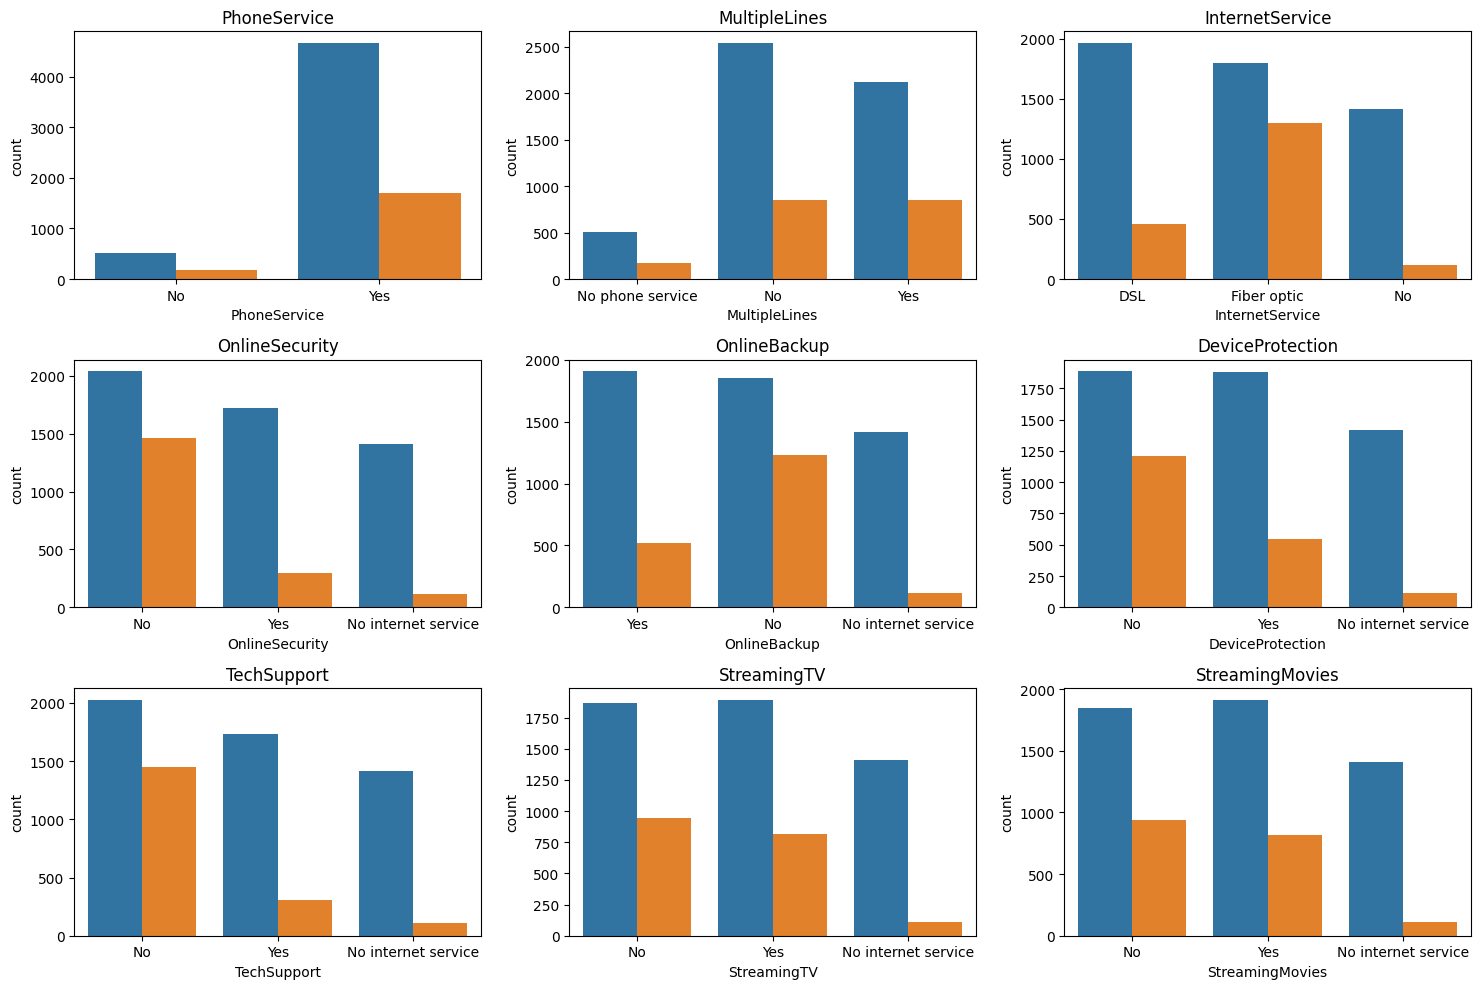

In [49]:
plt.figure(figsize=(15,10))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=col, data=df, hue="Churn")
    plt.title(col)
    plt.xticks(rotation=0)
    plt.legend([],[], frameon=False)  # remove repeated legends

plt.tight_layout()
plt.show()

Most customers have PhoneService and InternetService, with Fiber optic being the most common internet type. Customers without add-on services like OnlineSecurity, TechSupport, and DeviceProtection show noticeably higher churn compared to those who have these services. Streaming services (StreamingTV and StreamingMovies) are widely used but do not show a strong reduction in churn.

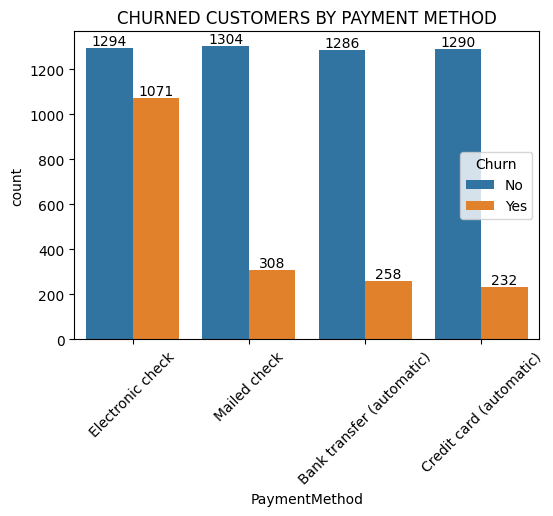

In [56]:
plt.figure(figsize=(6,4))
ax=sns.countplot(x="PaymentMethod",data=df,hue="Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("CHURNED CUSTOMERS BY PAYMENT METHOD")
plt.xticks(rotation=45)
plt.show()

customer is likely to churn when they are using electronic check as a payment method.